In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
print ('Library berhasil di import')

Library berhasil di import


In [ ]:
df = pd.read_csv('reactor_sample_5k.csv')

In [ ]:
print("Ukuran dataset:", df.shape)
print("\n5 Baris Pertama:")
df.head()


Ukuran dataset: (4901, 7)

5 Baris Pertama:


,Timestamp_min,Reactor_Temp_C,Jacket_Flow_Rate_L_min,Pressure_atm,Reactant_A_Conc_mol_L,Product_B_Conc_mol_L,Reactor_Run_ID
0,0,85.0,1015,3.20,2.50,0.00,1
1,1,84.5,1007,3.18,2.49,0.01,1
2,2,85.0,1012,3.22,2.48,0.02,1
3,3,85.5,1019,3.16,2.47,0.03,1
4,4,84.0,1002,3.21,2.46,0.04,1


In [ ]:
print("\n=== Informasi Dataset ===")
print(df.info())
print("\n=== Cek Missing Values ===")
print(df.isnull().sum())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4901 entries, 0 to 4900
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp_min           4901 non-null   int64  
 1   Reactor_Temp_C          4901 non-null   float64
 2   Jacket_Flow_Rate_L_min  4901 non-null   int64  
 3   Pressure_atm            4901 non-null   float64
 4   Reactant_A_Conc_mol_L   4901 non-null   float64
 5   Product_B_Conc_mol_L    4901 non-null   float64
 6   Reactor_Run_ID          4901 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 268.2 KB
None

=== Cek Missing Values ===
Timestamp_min             0
Reactor_Temp_C            0
Jacket_Flow_Rate_L_min    0
Pressure_atm              0
Reactant_A_Conc_mol_L     0
Product_B_Conc_mol_L      0
Reactor_Run_ID            0
dtype: int64


In [ ]:
print("\n=== Statistik Deskriptif ===")
print(df.describe())


=== Statistik Deskriptif ===
       Timestamp_min  Reactor_Temp_C  Jacket_Flow_Rate_L_min  Pressure_atm  \
count    4901.000000     4901.000000             4901.000000   4901.000000   
mean     2489.644970       88.206101             1012.611916      3.192659   
std      1456.621267        7.898097                8.740077      0.157271   
min         0.000000       60.500000              936.000000      2.220000   
25%      1225.000000       84.850000             1010.000000      3.170000   
50%      2450.000000       85.100000             1014.000000      3.200000   
75%      3775.000000       90.000000             1016.000000      3.220000   
max      5000.000000      110.000000             1063.000000      4.490000   

       Reactant_A_Conc_mol_L  Product_B_Conc_mol_L  Reactor_Run_ID  
count            4901.000000           4901.000000     4901.000000  
mean                1.401363              1.098000       14.552132  
std                 0.778582              0.778344        7.

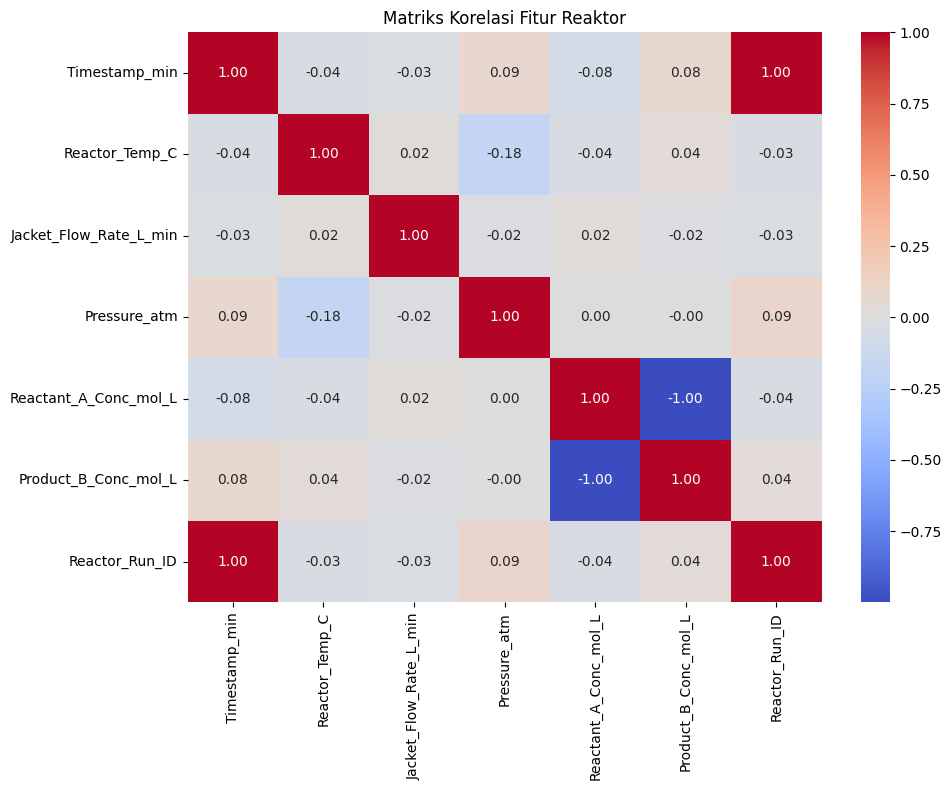

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi Fitur Reaktor")
plt.tight_layout()
plt.savefig('heatmap_korelasi.png')
plt.show()

In [ ]:
print(df.columns)

Index(['Timestamp_min', 'Reactor_Temp_C', 'Jacket_Flow_Rate_L_min',
       'Pressure_atm', 'Reactant_A_Conc_mol_L', 'Product_B_Conc_mol_L',
       'Reactor_Run_ID'],
      dtype='object')


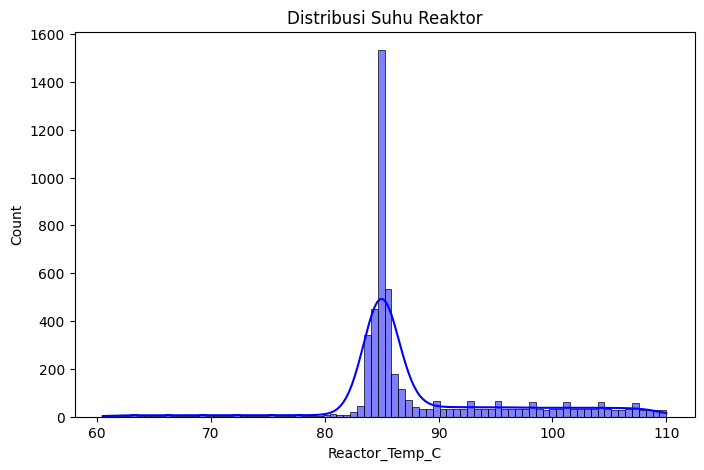

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Reactor_Temp_C'], kde=True, color='blue')
plt.title("Distribusi Suhu Reaktor")
plt.savefig('distribusi_suhu.png') # Menyimpan grafik statis
plt.show()

In [ ]:
df['Target_Defect'] = np.where(df['Reactor_Temp_C'] > 100, 1, 0)

fitur_reaktor = [
    'Reactor_Temp_C',
    'Jacket_Flow_Rate_L_min',
    'Pressure_atm',
    'Reactant_A_Conc_mol_L',
    'Product_B_Conc_mol_L'
]

X = df[fitur_reaktor]
y = df['Target_Defect']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

=== Akurasi Model ===
Akurasi: 1.0000

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       876
           1       1.00      1.00      1.00       105

    accuracy                           1.00       981
   macro avg       1.00      1.00      1.00       981
weighted avg       1.00      1.00      1.00       981



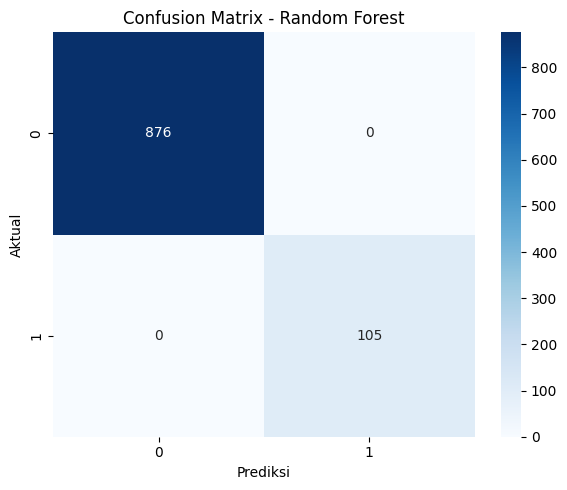

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)
print("=== Akurasi Model ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [11]:
joblib.dump(model, 'supervised_model.pkl')


joblib.dump(scaler, 'supervised_scaler.pkl')


joblib.dump(fitur_reaktor, 'supervised_features.pkl')

print("Semua file .pkl berhasil disimpan!")

Semua file .pkl berhasil disimpan!


In [12]:
!pip install gymnasium

In [13]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Catatan: Asumsikan dataset dari Anggota 1 tersimpan di variabel 'df'.
# Jika Anggota 1 menamainya 'data', ubah 'df' di bawah ini menjadi 'data'.

class BatchReactorEnv(gym.Env):
    def __init__(self, data, max_steps=50):
        super().__init__()
        self.data = data.reset_index(drop=True)
        self.max_steps = min(max_steps, len(self.data) - 1)

        # State (5 dimensi): Suhu, Tekanan, Reaktan, Produk, Coolant
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0], dtype=np.float32),
            high=np.array([200, 10, 5, 5, 50], dtype=np.float32),
            dtype=np.float32
        )

        # Action (3 opsi): 0 = Turunkan, 1 = Pertahankan, 2 = Naikkan aliran coolant
        self.action_space = spaces.Discrete(3)
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        row = self.data.iloc[0]
        self.state = np.array([
            row['Reactor_Temp_C'], row['Pressure_atm'],
            row['Reactant_A_Conc_mol_L'], row['Product_B_Conc_mol_L'],
            row['Jacket_Flow_Rate_L_min']
        ], dtype=np.float32)
        return self.state, {}

    def step(self, action):
        action_effect = {0: -2.0, 1: 0.0, 2: +2.0}
        self.current_step += 1

        if self.current_step < len(self.data):
            row = self.data.iloc[self.current_step]
            next_temp = row['Reactor_Temp_C'] + action_effect[action]
            next_coolant = row['Jacket_Flow_Rate_L_min'] + action_effect[action]
            next_pressure = row['Pressure_atm']
            next_reactant = row['Reactant_A_Conc_mol_L']
            next_product = row['Product_B_Conc_mol_L']
        else:
            next_temp = self.state[0] + action_effect[action]
            next_coolant = self.state[4] + action_effect[action]
            next_pressure, next_reactant, next_product = self.state[1], self.state[2], self.state[3]

        next_temp = np.clip(next_temp, 0, 200)
        next_coolant = np.clip(next_coolant, 0, 50)
        next_state = np.array([next_temp, next_pressure, next_reactant, next_product, next_coolant], dtype=np.float32)

        # Reward: Menjaga suhu tetap aman dan yield produk maksimal
        reward = 0
        if next_temp < 100: reward += 1.0
        else: reward -= 10.0
        if next_product > 0.5: reward += 2.0

        terminated = (next_temp > 120) or (self.current_step >= self.max_steps)
        self.state = next_state

        return next_state, reward, terminated, False, {}

In [14]:
# Ambil satu episode data untuk training
episode_data = df[df['Reactor_Run_ID'] == df['Reactor_Run_ID'].unique()[0]]
env = BatchReactorEnv(episode_data)

n_actions = env.action_space.n
n_bins = [20, 5, 5, 5, 10]
Q_table = np.zeros((np.prod(n_bins), n_actions))

learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
n_episodes = 500

def discretize_state(state, n_bins):
    bounds = [(0, 200), (0, 10), (0, 5), (0, 5), (0, 50)]
    indices = []
    for (val, (low, high), n_bin) in zip(state, bounds, n_bins):
        normalized = np.clip((val - low) / (high - low + 1e-8), 0, 1)
        indices.append(int(normalized * (n_bin - 1)))
    return np.ravel_multi_index(indices, n_bins)

rewards_per_episode = []

for episode in range(n_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        state_idx = discretize_state(state, n_bins)

        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_table[state_idx, :])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state_idx = discretize_state(next_state, n_bins)

        # Update Q-Table
        Q_table[state_idx, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state_idx, :]) - Q_table[state_idx, action]
        )

        state = next_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(0.01, epsilon * 0.995)

print("Proses Training Q-Learning Selesai!")

Proses Training Q-Learning Selesai!


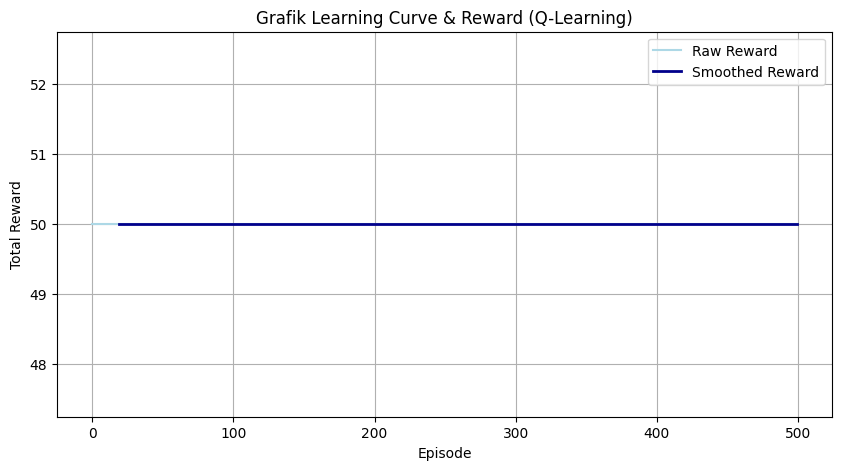

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_per_episode, color='lightblue', label='Raw Reward')

window = 20
smoothed_rewards = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards_per_episode)), smoothed_rewards, color='darkblue', linewidth=2, label='Smoothed Reward')

plt.title('Grafik Learning Curve & Reward (Q-Learning)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# 1. Simpan rl_qtable.pkl
with open('rl_qtable.pkl', 'wb') as f:
    pickle.dump(Q_table, f)

# 2. Simpan rl_metadata.pkl
metadata = {
    'n_bins': n_bins,
    'state_bounds': [(0, 200), (0, 10), (0, 5), (0, 5), (0, 50)],
    'actions': {0: 'Turunkan Coolant', 1: 'Pertahankan', 2: 'Naikkan Coolant'}
}
with open('rl_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("Berhasil menyimpan rl_qtable.pkl dan rl_metadata.pkl!")

Berhasil menyimpan rl_qtable.pkl dan rl_metadata.pkl!
